# 01 — Exploratory Data Analysis

Two goals:
1. **Pipeline step**: Process the `daily_crsp_raw.parquet`, `Chen_Zimmerman_monthly_raw.parquet`and `vix_raw.parquet`files.
2. **Motivate the feature set**: Based on litterature, we introduce several features that will be fed to our models.

| Feature group | Columns | Hypothesis |
|---|---|---|
| Short-term reversal | `log_reversal_1d` | Negative 1-day autocorrelation (microstructure) |
| Momentum | `mom_5d` → `mom_252d` | Intermediate-horizon price trend (Jegadeesh-Titman) |
| Volatility | `vol_21d` → `vol_252d` | Low-vol anomaly; risk normalizer for momentum |
| Vol-weighted momentum | `vol_w_mom_*` | Sharpe-like signal: momentum scaled by its own vol |
| Market return | `log_reversal_mkt_1d` | Broad market day-before signal |
| VIX | `vix`, `vix_ma_63/126/252` | Macro regime: high VIX → wider cross-sectional dispersion |
| Chen-Zimmerman (CZ) | 54 factors | Academic cross-sectional signals (accounting + market) |

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr
import config

from src.utils import *
from src.preprocessing import *
from src.feature_engineering import *

os.makedirs(str(config.PLOTS_DIR), exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)
print(f'Window : {config.START_DATE} → {config.END_DATE}')
print(f'Split  : train ≤2015 | val 2015-2018 | test 2018-2021')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Window : 2000-01-01 → 2020-11-30
Split  : train ≤2015 | val 2015-2018 | test 2018-2021


---
### Daily crsp processed

We drop rows where return is missing, restrict to project date window and clip extreme returns at ±300%

In [2]:
crsp = clean_crsp()
crsp.head()

Saved as .parquet file to /Users/leowunderli/Documents/EPFL/MA2/ML_finance/01_ML_project/notebooks/../data/processed/daily_crsp.parquet


,PERMNO,date,ret,mkt_ret
0,10001,2000-01-03,0.0074,-0.0095
1,10001,2000-01-04,-0.0146,-0.0383
2,10001,2000-01-05,0.0148,0.0019
3,10001,2000-01-06,-0.0073,0.0010
4,10001,2000-01-07,-0.0074,0.0271


### Chen-Zimmerman monthly processed

We get rid of columns with too many NaN. The threshold is set at 90% default, but can be changed. One of the two columns with too high absolute correlation with another column is dropped. The threshold is set at 0.95 default but can be changed.

In [3]:
cz = clean_cz_monthly()
cz.head(3)

Saved as .parquet file to /Users/leowunderli/Documents/EPFL/MA2/ML_finance/01_ML_project/notebooks/../data/processed/Chen_Zimmerman_monthly.parquet


,date,Beta,BetaFP,BetaTailRisk,BidAskSpread,CompEquIss,Coskewness,DivInit,DivOmit,DivSeason,...,Size,Spinoff,std_turn,STreversal,VolMkt,VolSD,VolumeTrend,zerotrade,zerotradeAlt1,zerotradeAlt12
26999,2000-01-01,0.2206,0.2043,0.1139,0.1176,0.0365,-0.0265,-0.0565,0.0800,0.0091,...,0.0151,0.1267,-0.0398,-0.1941,-0.1413,-0.0259,0.0009,-0.0531,-0.0383,-0.0343
27000,2000-01-02,0.2206,0.2043,0.1139,0.1176,0.0365,-0.0265,-0.0565,0.0800,0.0091,...,0.0151,0.1267,-0.0398,-0.1941,-0.1413,-0.0259,0.0009,-0.0531,-0.0383,-0.0343
27001,2000-01-03,0.2206,0.2043,0.1139,0.1176,0.0365,-0.0265,-0.0565,0.0800,0.0091,...,0.0151,0.1267,-0.0398,-0.1941,-0.1413,-0.0259,0.0009,-0.0531,-0.0383,-0.0343


### VIX processed
We drop the duplicates and NaN and create the moving averages stored in `config.py`

In [4]:
vix = clean_vix()
vix.head(3)

Saved as .parquet file to /Users/leowunderli/Documents/EPFL/MA2/ML_finance/01_ML_project/notebooks/../data/processed/vix.parquet


,vix,vix_ma_63,vix_ma_126,vix_ma_252
date,,,,
2001-01-02,0.2685,0.2602,0.2259,0.2332
2001-01-03,0.2999,0.2616,0.2267,0.2334
2001-01-04,0.2660,0.2623,0.2272,0.2334


---
## 1. Feature Engineering

We build the full feature set from the clean CRSP returns (`crsp` produced above).
All signals are shifted so that on day $t$ only data from $t-1$ and earlier is used.
Returns were already clipped at ±300% during preprocessing.

| Feature group | Columns | Construction |
|---|---|---|
| Short-term reversal | `log_reversal_1d` | $\log(1+r_{t-1})$ |
| Momentum | `mom_{5,21,63,126,252}d` | Cumulative log return, shifted 1 day |
| Volatility | `vol_{21,63,252}d` | Annualised rolling std, shifted 1 day |
| Vol-weighted momentum | `vol_w_mom_{w}d` | Momentum / realized vol (Sharpe-like) |
| Market return | `log_reversal_mkt_1d` | $\log(1+r_{\text{mkt},t-1})$ (macro — not rank-normalised) |

Stock-level features are **cross-sectionally rank-normalised** to $[-0.5,\,0.5]$ per date.

In [5]:
# 1. Raw features (no rank norm) — used for distribution analysis in section 5
feat_raw = polars_features(crsp, value_col='ret', date_col='date', target_col='ret',
                           crosssectional_rank=False).to_pandas()

# 2. Rank-normalised features — the model input saved to parquet
feat = polars_features(crsp, value_col='ret', date_col='date', target_col='ret',
                       crosssectional_rank=True)
feat = shrink_polars(feat).to_pandas()
feat.to_parquet(config.FEATURES_PATH_CLEAN, compression='zstd', index=False)

feat_cols = [c for c in feat.columns if c not in {'PERMNO','date','ret','mkt_ret','target'}]
cs_cols   = [c for c in feat_cols if c != 'log_reversal_mkt_1d']

print(f'Saved  → {config.FEATURES_PATH_CLEAN}')
print(f'Shape  : {feat.shape}  |  Stocks: {feat["PERMNO"].nunique():,}  |  Dates: {feat["date"].nunique():,}')
print(f'date dtype : {feat["date"].dtype}')
print(f'\nFeature columns ({len(feat_cols)}): {feat_cols}')

Saved  → /Users/leowunderli/Documents/EPFL/MA2/ML_finance/01_ML_project/notebooks/../data/processed/features.parquet
Shape  : (17917302, 20)  |  Stocks: 7,355  |  Dates: 5,262
date dtype : datetime64[ms]

Feature columns (15): ['log_reversal_1d', 'log_reversal_mkt_1d', 'mom_5d', 'mom_21d', 'mom_63d', 'mom_126d', 'mom_252d', 'vol_21d', 'vol_63d', 'vol_252d', 'vol_w_mom_5d_std_5d', 'vol_w_mom_21d_std_21d', 'vol_w_mom_63d_std_63d', 'vol_w_mom_126d_std_126d', 'vol_w_mom_252d_std_252d']


---
## 2. Return distribution

Understanding the marginal distribution of daily returns informs two preprocessing choices:
- **Clipping to ±300%** in preprocessing: removes data errors and extreme delisting returns that would distort rolling windows.
- **Cross-sectional rank normalization**: maps each feature to [−0.5, 0.5] per date, removing time-varying scale and distributional asymmetries.

Rows   : 17,917,302  |  Stocks : 7,355
Dates  : 2000-01-03 → 2020-11-30

Skewness : 4.80  |  Excess kurtosis : 218.3
count   17917302.0000
mean           0.0007
std            0.0401
min           -1.0000
1%            -0.1047
5%            -0.0487
25%           -0.0118
50%            0.0000
75%            0.0117
95%            0.0500
99%            0.1196
max            3.0000
Name: ret, dtype: float64


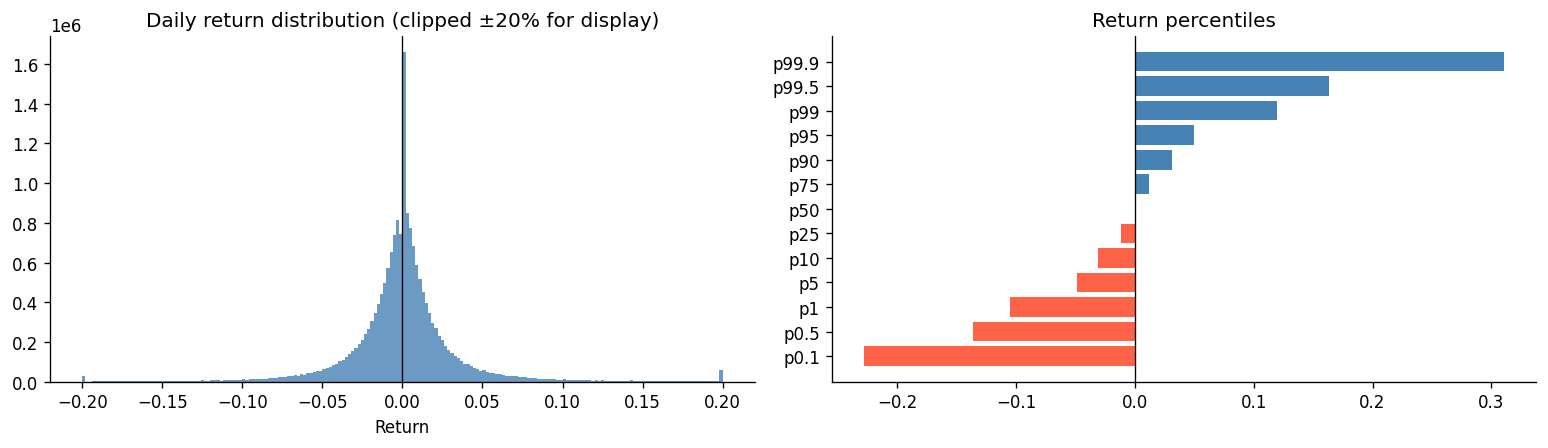

In [6]:
crsp['date'] = pd.to_datetime(crsp['date'])
ret = crsp['ret']

print(f'Rows   : {len(crsp):,}  |  Stocks : {crsp["PERMNO"].nunique():,}')
print(f'Dates  : {crsp["date"].min().date()} → {crsp["date"].max().date()}')
print(f'\nSkewness : {ret.skew():.2f}  |  Excess kurtosis : {ret.kurtosis():.1f}')
print(ret.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ret.clip(-0.20, 0.20), bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Daily return distribution (clipped ±20% for display)')
axes[0].set_xlabel('Return')

pcts = [0.1, 0.5, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
q = np.percentile(ret.dropna(), pcts)
axes[1].barh(range(len(pcts)), q,
             color=['tomato' if v < 0 else 'steelblue' for v in q])
axes[1].set_yticks(range(len(pcts)))
axes[1].set_yticklabels([f'p{p}' for p in pcts])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Return percentiles')

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/crsp_return_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Universe size & coverage

Cross-sectional signals (rank IC, long-short portfolios) require a large, stable universe. The plot below shows the number of active stocks per month.

Min: 1,763  Median: 2,941  Max: 7,355


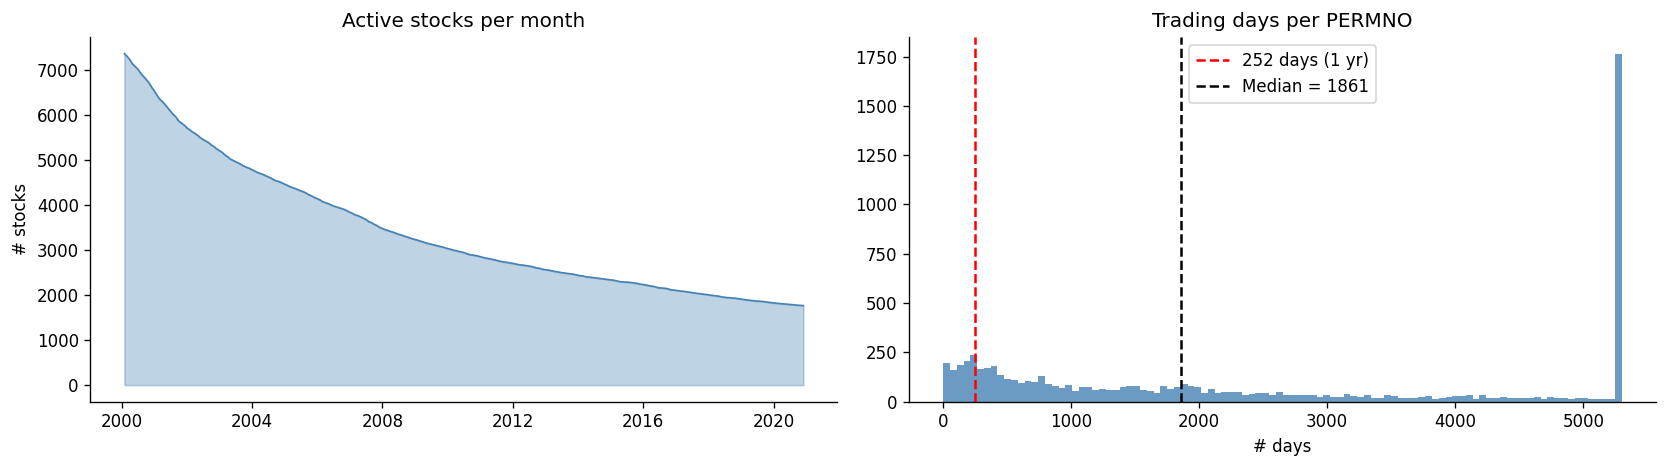

Stocks < 1 year of data: 920 (12.5%)


In [7]:
monthly = crsp.set_index('date').resample('ME')['PERMNO'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].fill_between(monthly.index, monthly.values, alpha=0.35, color='steelblue')
axes[0].plot(monthly.index, monthly.values, color='steelblue', lw=1)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].set_title('Active stocks per month')
axes[0].set_ylabel('# stocks')
print(f'Min: {monthly.min():,}  Median: {int(monthly.median()):,}  Max: {monthly.max():,}')

obs_per_stock = crsp.groupby('PERMNO').size()
axes[1].hist(obs_per_stock, bins=100, color='steelblue', alpha=0.8)
axes[1].axvline(252, color='red', lw=1.5, ls='--', label='252 days (1 yr)')
axes[1].axvline(int(obs_per_stock.median()), color='black', lw=1.5, ls='--',
                label=f'Median = {int(obs_per_stock.median())}')
axes[1].set_title('Trading days per PERMNO')
axes[1].set_xlabel('# days')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/crsp_universe_size.png', bbox_inches='tight')
plt.show()
print(f'Stocks < 1 year of data: {(obs_per_stock < 252).sum():,} ({(obs_per_stock < 252).mean()*100:.1f}%)')

**Takeaway:** 5 000 – 8 000 stocks active per day. The large cross-section means each date provides hundreds to thousands of ranked observations — enough for stable rank IC estimates and robust long-short portfolios.

---
## 4. Cumulative returns: market vs equal-weighted

Sanity-check that the data spans the main market regimes (dot-com crash, GFC, COVID).

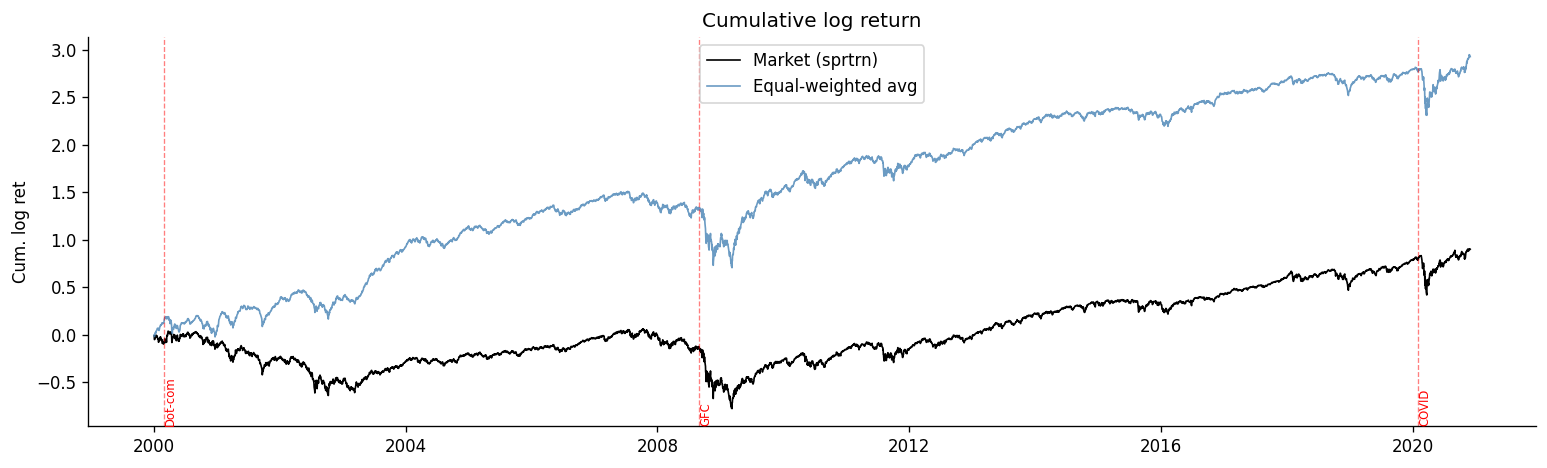

In [8]:
daily = crsp.groupby('date').agg(
    ew_ret=('ret', 'mean'),
    mkt_ret=('mkt_ret', 'first'),
).reset_index()
daily['cum_ew']  = np.log1p(daily['ew_ret']).cumsum()
daily['cum_mkt'] = np.log1p(daily['mkt_ret']).cumsum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['date'], daily['cum_mkt'], label='Market (sprtrn)', color='black', lw=1)
ax.plot(daily['date'], daily['cum_ew'],  label='Equal-weighted avg', color='steelblue', lw=1, alpha=0.8)
for yr, label in [('2000-03', 'Dot-com'), ('2008-09', 'GFC'), ('2020-02', 'COVID')]:
    ax.axvline(pd.Timestamp(yr), color='red', lw=0.8, ls='--', alpha=0.5)
    ax.text(pd.Timestamp(yr), ax.get_ylim()[0], label, fontsize=7, color='red', rotation=90, va='bottom')
ax.legend()
ax.set_title('Cumulative log return')
ax.set_ylabel('Cum. log ret')
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/crsp_cumulative_returns.png', bbox_inches='tight')
plt.show()

---
## 5. Feature Distributions

We inspect the raw marginal distributions (before rank normalization). This motivates clipping at ±50% (heavy tails) and cross-sectional rank normalization (scale varies across windows and over time).

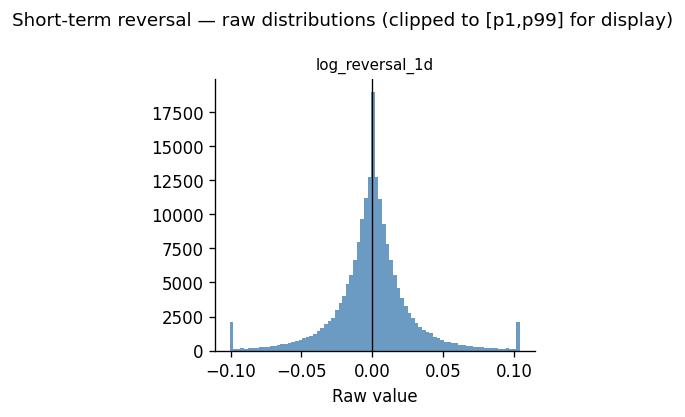

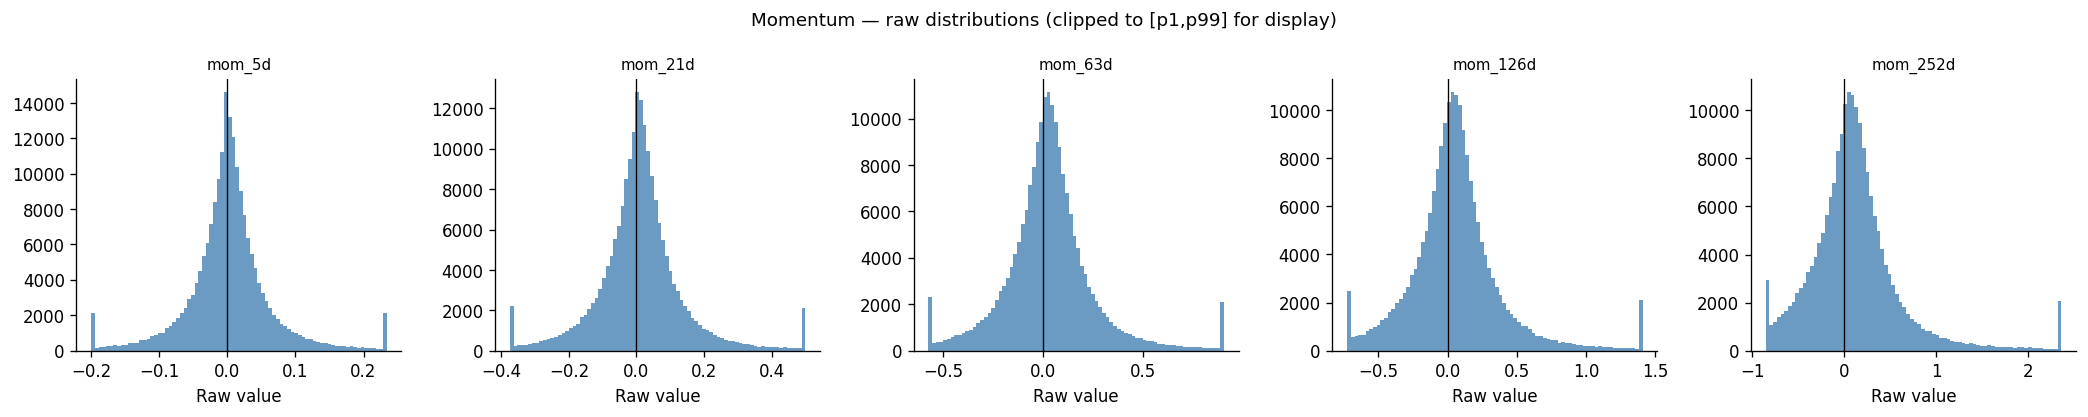

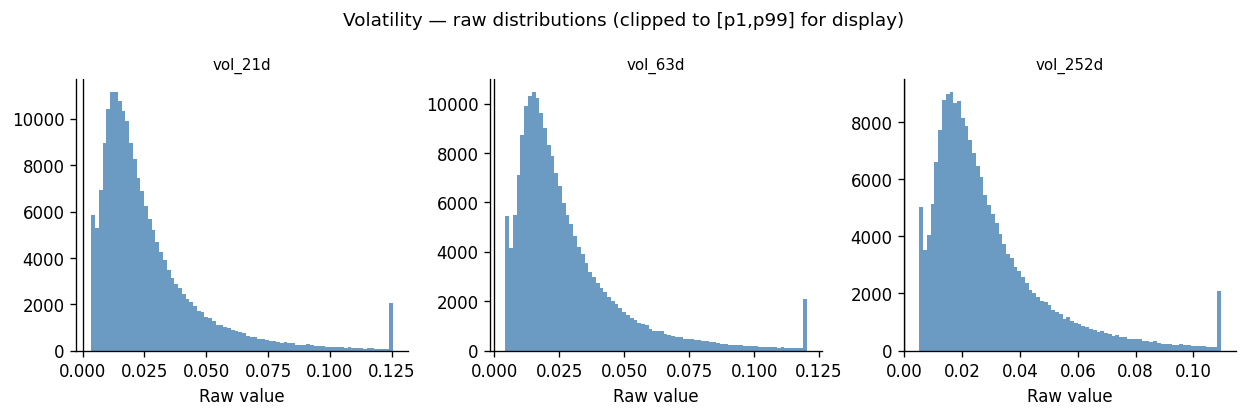

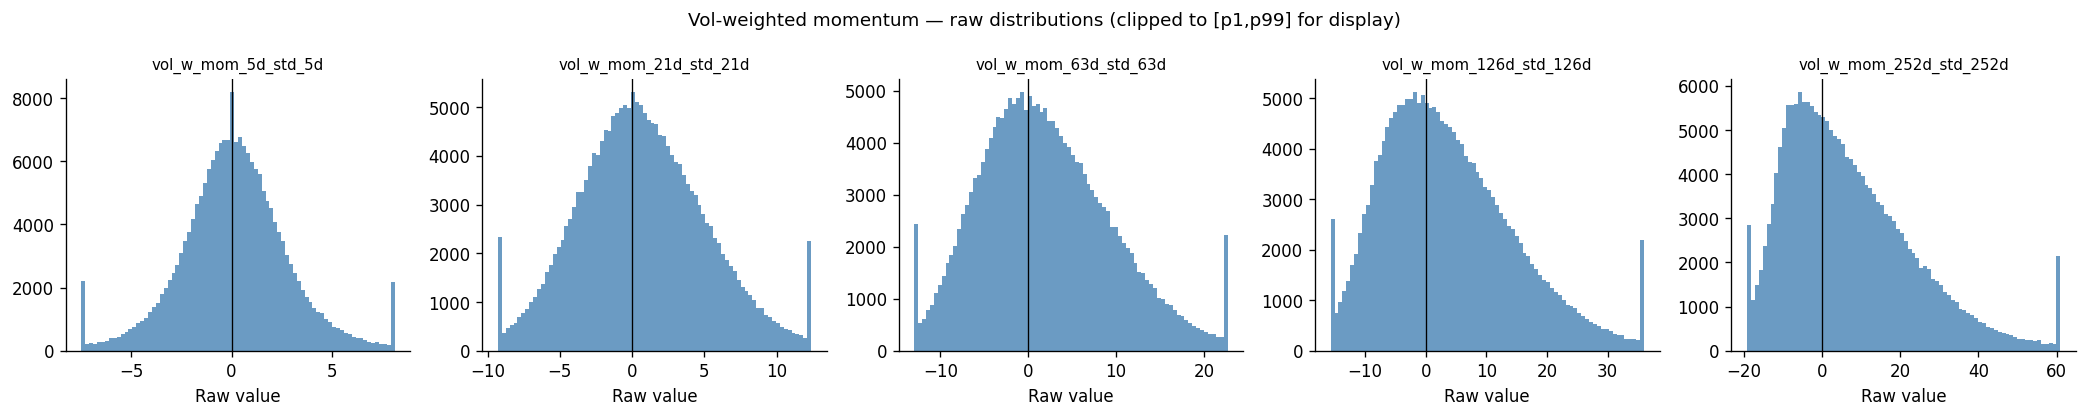

In [9]:
groups = {
    'Short-term reversal': ['log_reversal_1d'],
    'Momentum':            [f'mom_{w}d' for w in config.MOMENTUM_WINDOWS],
    'Volatility':          [f'vol_{w}d' for w in config.VOLATILITY_WINDOWS],
    'Vol-weighted momentum': [f'vol_w_mom_{w}d_std_{w}d' for w in config.MOMENTUM_WINDOWS],
}

sample = feat_raw.dropna().sample(min(200_000, len(feat_raw)), random_state=42)

for group_name, cols in groups.items():
    cols = [c for c in cols if c in sample.columns]
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        vals = sample[col].dropna()
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', edgecolor='none', alpha=0.8)
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('Raw value')
    fig.suptitle(f'{group_name} — raw distributions (clipped to [p1,p99] for display)', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{config.PLOTS_DIR}/{group_name.lower().replace(" ", "_")}_raw_distributions.png', bbox_inches='tight')
    plt.show()

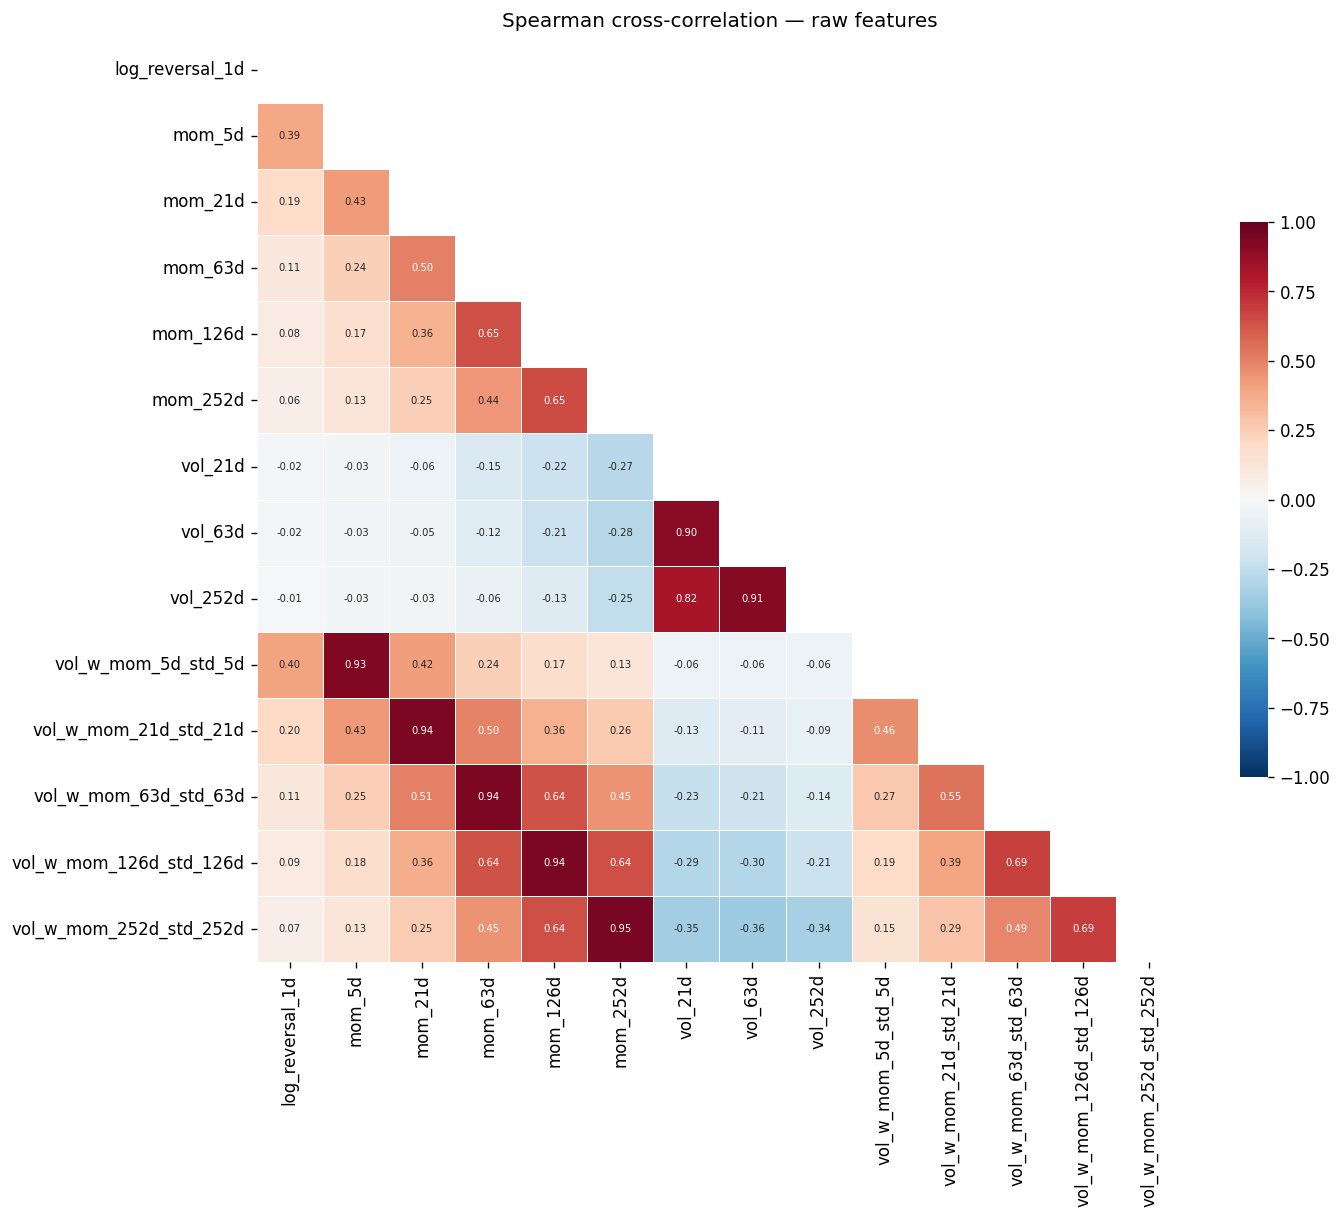

In [10]:
import seaborn as sns

raw_for_corr = [c for c in feat_raw.columns
                if c not in {'PERMNO','date','ret','mkt_ret','target','log_reversal_mkt_1d'}
                and c in feat_raw.columns]

sample_c = feat_raw[raw_for_corr].dropna().sample(min(100_000, len(feat_raw)), random_state=42)
corr = sample_c.corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.6}, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 6})
ax.set_title('Spearman cross-correlation — raw features')
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/feature_spearman_correlation.png', bbox_inches='tight')
plt.show()

**Takeaway:** Momentum features are strongly correlated across windows (returns compound). Volatility features are moderately correlated with each other but less so with momentum. Vol-weighted momentum inherits both groups but adds new information by normalizing for risk.

---
## 6. Rank IC Analysis

**Rank IC** (Spearman correlation between a feature at $t$ and next-day return) quantifies predictive signal. Computed cross-sectionally for each trading day, then aggregated:
- **Mean IC**: average signal strength across dates
- **t-statistic**: mean IC / (std / √N) — tests whether mean IC is significantly different from zero
- **IC > 0 %**: fraction of days with correct directional signal

`log_reversal_mkt_1d` is excluded — it is the same for all stocks on a given date, so cross-sectional IC is undefined.

In [11]:
ic = rank_ic_table(feat, cs_cols)
ic.style.format({'mean_IC': '{:.4f}', 't_stat': '{:.2f}', 'IC_std': '{:.4f}', 'IC>0_pct': '{:.1%}'}) \
   .background_gradient(subset=['t_stat'], cmap='RdBu_r', vmin=-5, vmax=5)

,mean_IC,t_stat,IC_std,IC>0_pct
feature,,,,
log_reversal_1d,-0.0573,-36.05,0.1153,26.0%
mom_5d,-0.0405,-25.20,0.1166,32.9%
vol_w_mom_5d_std_5d,-0.0342,-24.90,0.0995,33.5%
vol_63d,-0.0267,-12.39,0.1553,43.2%
mom_21d,-0.0196,-12.38,0.1146,42.7%
vol_252d,-0.0249,-11.80,0.1491,43.5%
vol_21d,-0.0253,-11.68,0.1568,43.4%
vol_w_mom_21d_std_21d,-0.0160,-10.91,0.1058,43.5%
vol_w_mom_252d_std_252d,0.0099,5.46,0.1279,54.6%


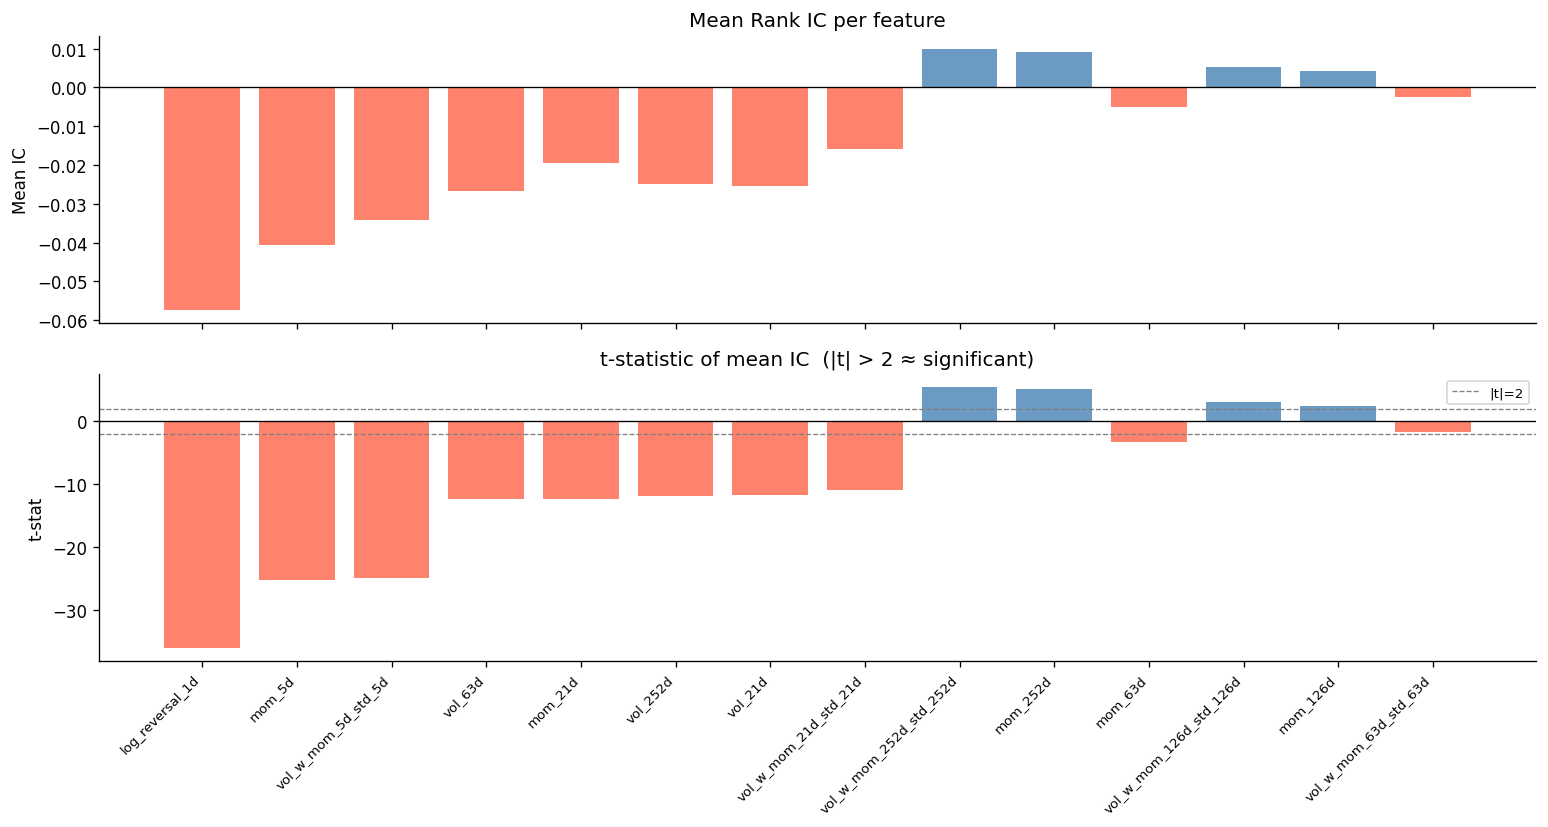

In [12]:
top5 = ic['t_stat'].abs().nlargest(5).index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

colors = ['tomato' if v < 0 else 'steelblue' for v in ic['mean_IC']]
axes[0].bar(range(len(ic)), ic['mean_IC'].values, color=colors, alpha=0.8)
axes[0].set_xticks(range(len(ic)))
axes[0].set_xticklabels(ic.index, rotation=45, ha='right', fontsize=8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Mean Rank IC per feature')
axes[0].set_ylabel('Mean IC')

axes[1].bar(range(len(ic)), ic['t_stat'].values, color=colors, alpha=0.8)
axes[1].set_xticks(range(len(ic)))
axes[1].set_xticklabels(ic.index, rotation=45, ha='right', fontsize=8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axhline( 2, color='gray', ls='--', lw=0.8, label='|t|=2')
axes[1].axhline(-2, color='gray', ls='--', lw=0.8)
axes[1].set_title('t-statistic of mean IC  (|t| > 2 ≈ significant)')
axes[1].set_ylabel('t-stat')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/feature_rank_ic.png', bbox_inches='tight')
plt.show()

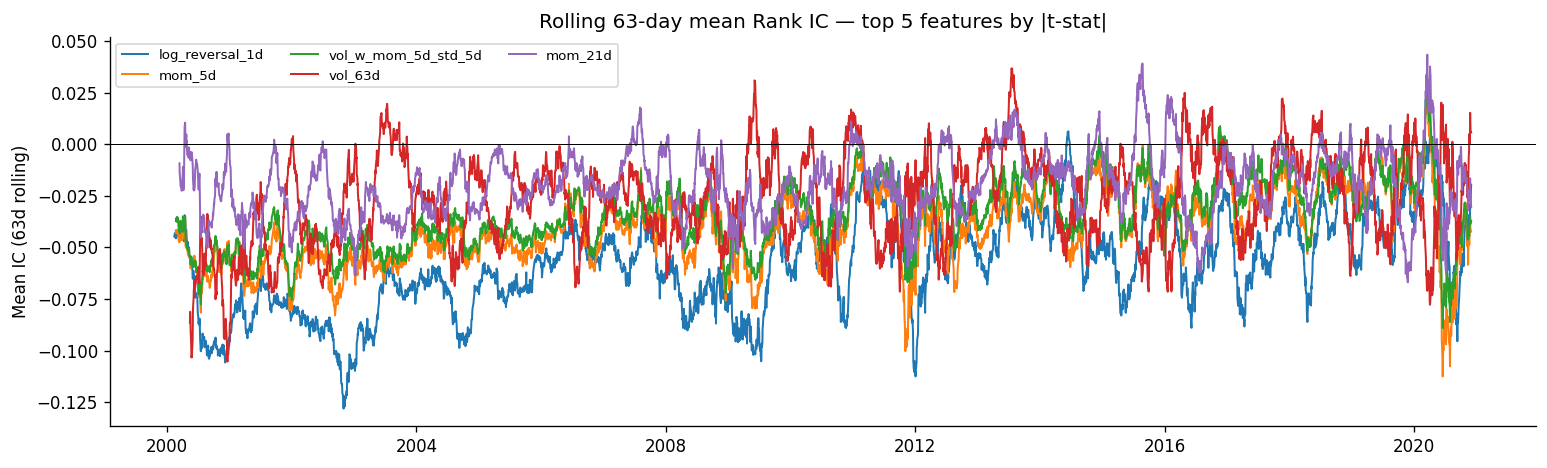

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))

for col in top5:
    sub = feat[['date', col, 'target']].dropna()
    ic_ts = (
        sub.groupby('date')
        .apply(lambda g: spearmanr(g[col], g['target'])[0] if len(g) > 10 else np.nan,
               include_groups=False)
        .dropna()
        .rolling(63, min_periods=30).mean()
    )
    ax.plot(ic_ts.index, ic_ts.values, label=col, lw=1.2)

ax.axhline(0, color='black', lw=0.6)
ax.legend(ncol=3, fontsize=8)
ax.set_title('Rolling 63-day mean Rank IC — top 5 features by |t-stat|')
ax.set_ylabel('Mean IC (63d rolling)')
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/feature_rank_ic_rolling.png', bbox_inches='tight')
plt.show()

**Takeaway:**
- **`log_reversal_1d`** has a reliably **negative** IC: stocks up yesterday tend to fall tomorrow (microstructure mean-reversion).
- **Momentum** at 21d–126d has a **positive** IC: consistent with Jegadeesh-Titman (1993). The 252d window turns negative at long horizons (De Bondt-Thaler reversal).
- **`vol_w_mom_*`** (momentum / realized vol) amplifies the momentum signal by normalizing for risk — typically the strongest and most stable IC.
- **`vol_*`** features capture the low-volatility anomaly.

---
## 7. VIX — macro regime signal

VIX measures implied equity volatility and serves as a real-time market stress indicator. We use it as a macro feature (not rank-normalized since it is the same for all stocks on a given day) to let the model adapt to changing market conditions.

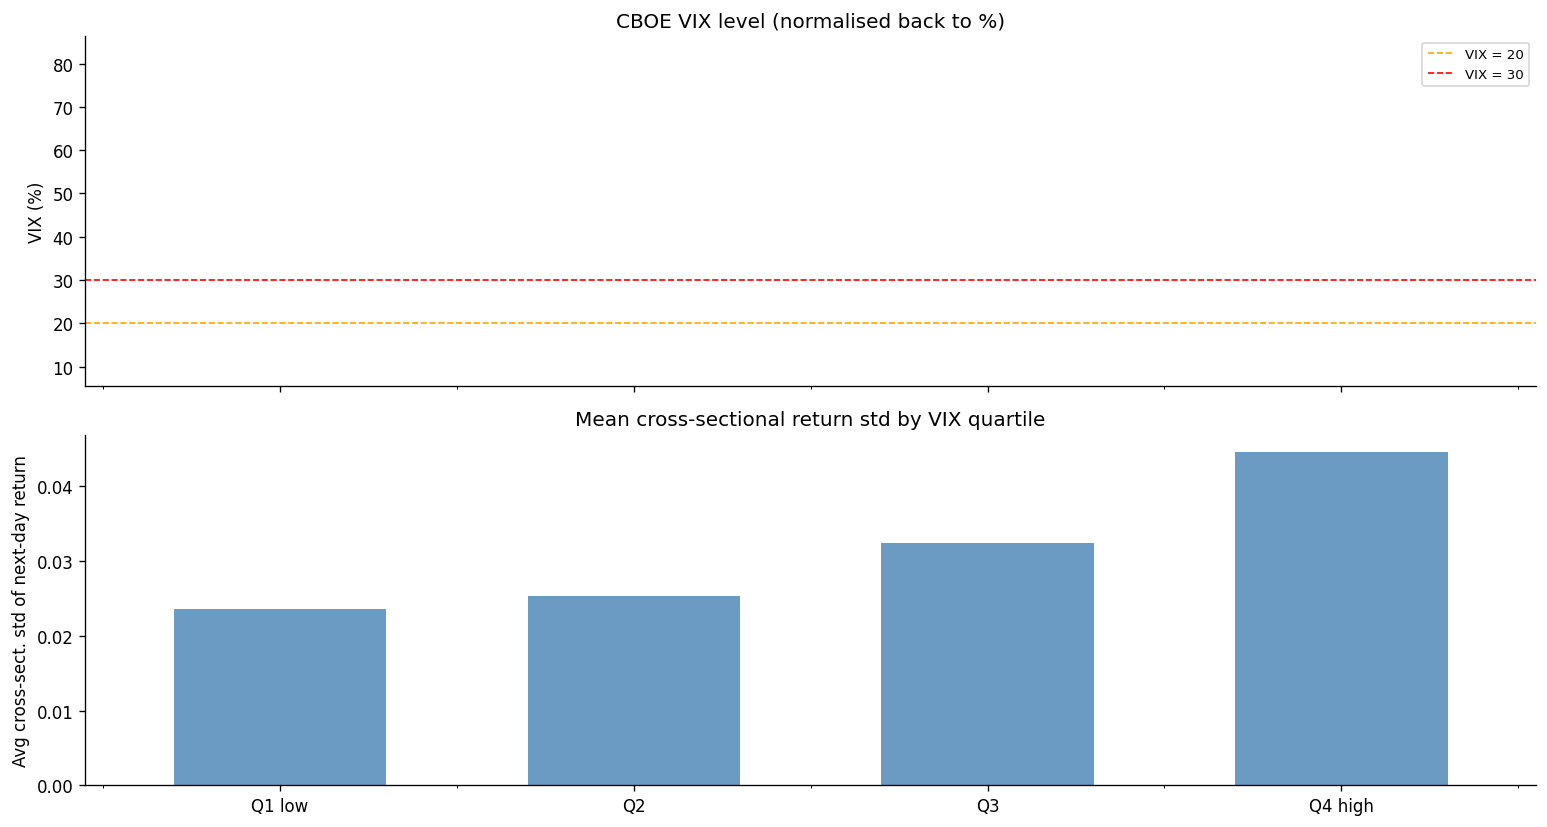

VIX features used as model inputs: ['vix', 'vix_ma_63', 'vix_ma_126', 'vix_ma_252']


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

vix_pct = vix['vix'] * 100
axes[0].plot(vix.index, vix_pct, color='steelblue', lw=0.8)
axes[0].axhline(20, color='orange', lw=1, ls='--', label='VIX = 20')
axes[0].axhline(30, color='red',    lw=1, ls='--', label='VIX = 30')
for start, end in [('2000-03','2002-10'), ('2008-09','2009-06'), ('2020-02','2020-05')]:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color='red')
axes[0].set_title('CBOE VIX level (normalised back to %)')
axes[0].set_ylabel('VIX (%)')
axes[0].legend(fontsize=8)

# Cross-sectional return dispersion vs VIX quartile
# Force date dtype to match feat['date'] before merging
vix_daily = vix['vix'].reset_index()
vix_daily.columns = ['date', 'vix_norm']
vix_daily['date'] = vix_daily['date'].astype(feat['date'].dtype)

feat_m = feat[['date', 'target']].merge(vix_daily, on='date', how='left').dropna()
feat_m['vix_q'] = pd.qcut(feat_m['vix_norm'], 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
cs_std = (feat_m.groupby(['date', 'vix_q'], observed=True)['target'].std()
                .groupby('vix_q', observed=True).mean())

cs_std.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8, edgecolor='none', width=0.6)
axes[1].set_title('Mean cross-sectional return std by VIX quartile')
axes[1].set_ylabel('Avg cross-sect. std of next-day return')
axes[1].set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/vix_and_return_dispersion.png', bbox_inches='tight')
plt.show()

print('VIX features used as model inputs:', list(vix.columns))

**Takeaway:** Cross-sectional return dispersion rises monotonically with VIX. Including VIX level and its moving averages as macro features lets the model weight cross-sectional signals more or less aggressively depending on the macro regime.

---
## 8. Chen-Zimmerman factor EDA

The Chen-Zimmerman (2022) dataset contains monthly **long-short portfolio returns** from published academic papers. Each factor is a single number per month (the return of a long-short sort on stocks). After forward-filling to daily frequency and shifting by one day, they serve as **macro / regime features** — identical across all stocks on a given date, much like VIX.

Because they are market-level (not stock-level), **cross-sectional IC is undefined** for these factors. Instead we study their time-series properties.

CZ factors retained : 54
Date range          : 2000-01-01 → 2020-11-30
Factors             : ['Beta', 'BetaFP', 'BetaTailRisk', 'BidAskSpread', 'CompEquIss', 'Coskewness', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'DolVol', 'FirmAge', 'FirmAgeMom', 'High52', 'IdioRisk', 'IdioVolAHT', 'Illiquidity', 'IndMom', 'IndRetBig', 'IntMom', 'LRreversal', 'MaxRet', 'Mom12m', 'Mom12mOffSeason', 'Mom6m', 'MomOffSeason', 'MomOffSeason06YrPlus', 'MomRev', 'MomSeason', 'MomSeason06YrPlus', 'MomSeasonShort', 'MomVol', 'MRreversal', 'PriceDelayRsq', 'PriceDelaySlope', 'PriceDelayTstat', 'ResidualMomentum', 'ReturnSkew', 'ReturnSkew3F', 'RIO_Turnover', 'RIO_Volatility', 'ShareIss1Y', 'ShareIss5Y', 'ShareVol', 'Size', 'Spinoff', 'std_turn', 'STreversal', 'VolMkt', 'VolSD', 'VolumeTrend', 'zerotrade', 'zerotradeAlt1', 'zerotradeAlt12']


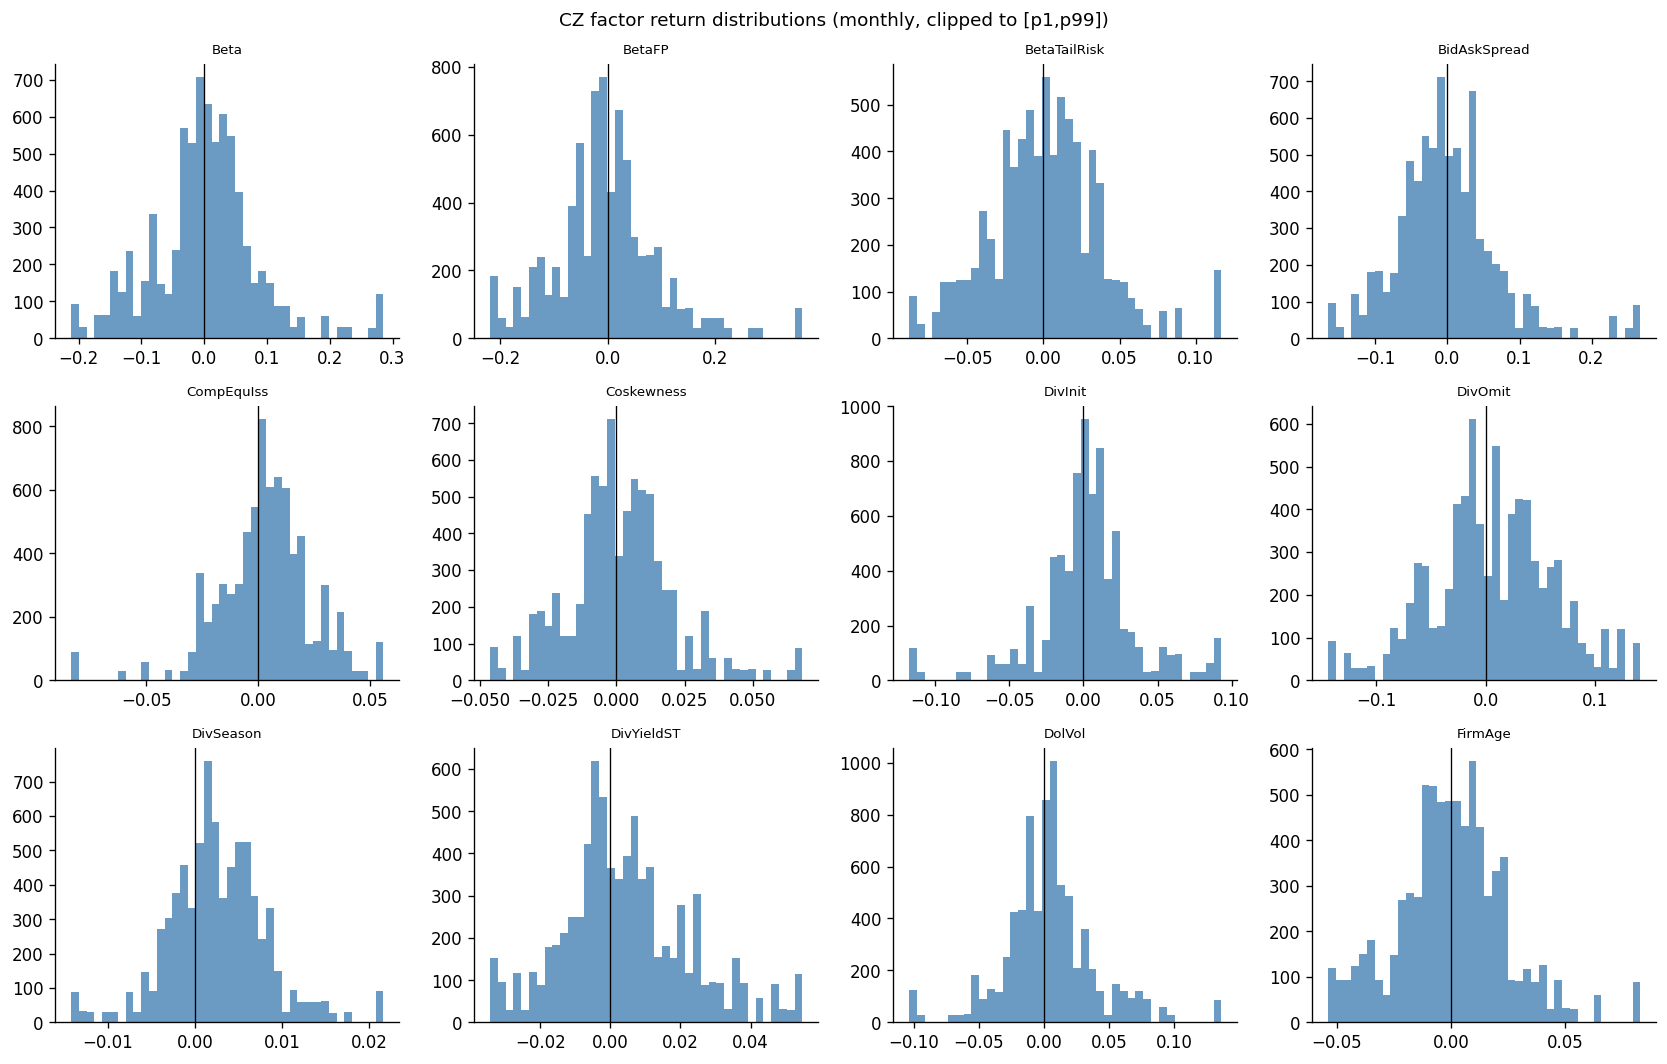

In [15]:
# cz is already in scope from clean_cz_monthly() above
cz_cols = [c for c in cz.columns if c != 'date']
print(f'CZ factors retained : {len(cz_cols)}')
print(f'Date range          : {cz["date"].min().date()} → {cz["date"].max().date()}')
print(f'Factors             : {cz_cols}')

# ── Distribution of retained factor returns ───────────────────────────────────
sample_factors = cz_cols[:min(12, len(cz_cols))]   # first 12 for display
n = len(sample_factors)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = axes.flatten()
for ax, col in zip(axes, sample_factors):
    vals = cz[col].dropna()
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(col, fontsize=8)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('CZ factor return distributions (monthly, clipped to [p1,p99])', fontsize=11)
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/cz_factor_distributions.png', bbox_inches='tight')
plt.show()

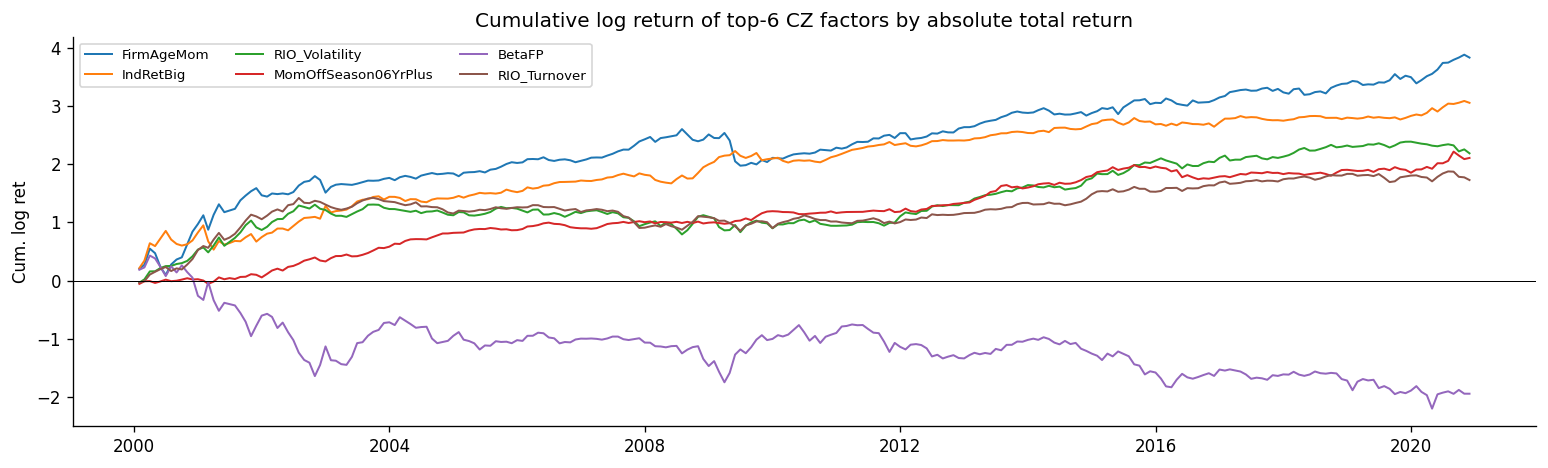

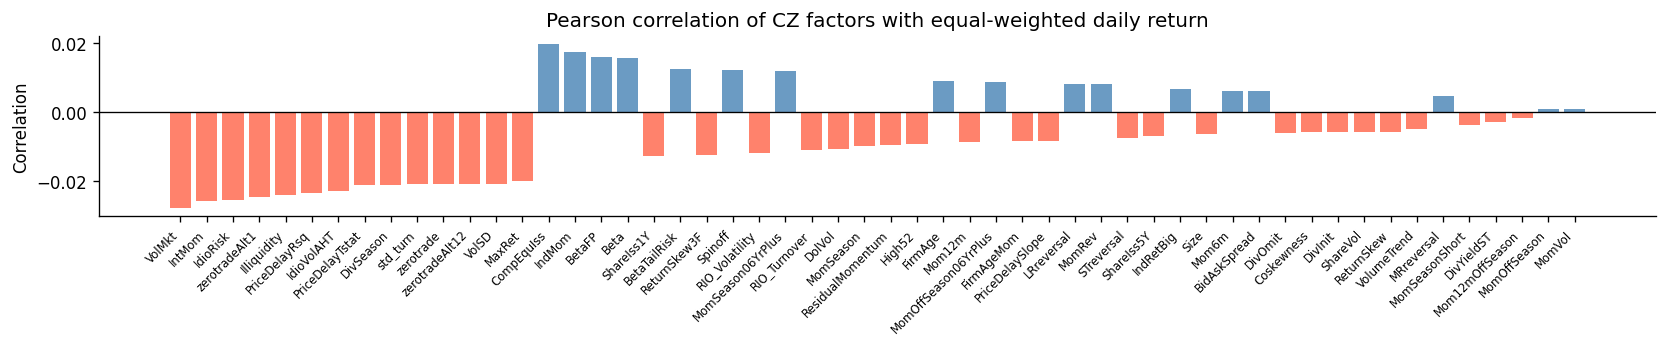

In [16]:
# ── Cumulative returns of a sample of CZ factors ─────────────────────────────
# Resample to monthly (take first value per month — already constant within month)
cz_monthly = cz.copy()
cz_monthly['date'] = pd.to_datetime(cz_monthly['date'])
cz_monthly = cz_monthly.set_index('date').resample('ME').first()

# Pick factors with the highest absolute cumulative return for display
cum = cz_monthly[cz_cols].apply(lambda s: np.log1p(s).cumsum())
top6 = cum.iloc[-1].abs().nlargest(6).index.tolist()

fig, ax = plt.subplots(figsize=(13, 4))
for col in top6:
    ax.plot(cum.index, cum[col], label=col, lw=1.2)
ax.axhline(0, color='black', lw=0.6)
ax.legend(ncol=3, fontsize=8)
ax.set_title('Cumulative log return of top-6 CZ factors by absolute total return')
ax.set_ylabel('Cum. log ret')
plt.tight_layout()
plt.show()

# ── Time-series correlation with equal-weighted market return ─────────────────
daily_ew = crsp.groupby('date')['ret'].mean().reset_index()
daily_ew.columns = ['date', 'ew_ret']
daily_ew['date'] = daily_ew['date'].astype(cz_monthly.index.dtype)

ts = daily_ew.merge(cz.assign(date=pd.to_datetime(cz['date'])), on='date', how='inner')
ts_corr = {col: ts['ew_ret'].corr(ts[col]) for col in cz_cols}
ts_corr = pd.Series(ts_corr).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 3))
colors_ts = ['tomato' if v < 0 else 'steelblue' for v in ts_corr.values]
ax.bar(range(len(ts_corr)), ts_corr.values, color=colors_ts, alpha=0.8)
ax.set_xticks(range(len(ts_corr)))
ax.set_xticklabels(ts_corr.index, rotation=45, ha='right', fontsize=7)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Pearson correlation of CZ factors with equal-weighted daily return')
ax.set_ylabel('Correlation')
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/cz_factor_correlations.png', bbox_inches='tight')
plt.show()

**Takeaway:** CZ factors are market-level time-series signals (one value per date). Their distribution and persistence over time is visible in the cumulative return plot. Correlation with the equal-weighted daily return is generally low — as expected since these are long-short portfolio returns measured monthly. They contribute regime information as macro features alongside VIX.

---
## 9. Train / validation / test split

All splits are **strictly chronological** to prevent look-ahead bias. The 70 / 15 / 15 ratio by trading days corresponds approximately to 2000–2015 / 2015–2018 / 2018–2021.

Total unique dates: 5262
  train: 2000-01-03 → 2014-08-22  (3683 dates, 70.0%)
  val  : 2014-08-25 → 2017-10-10  (789 dates, 15.0%)
  test : 2017-10-11 → 2020-11-30  (790 dates, 15.0%)


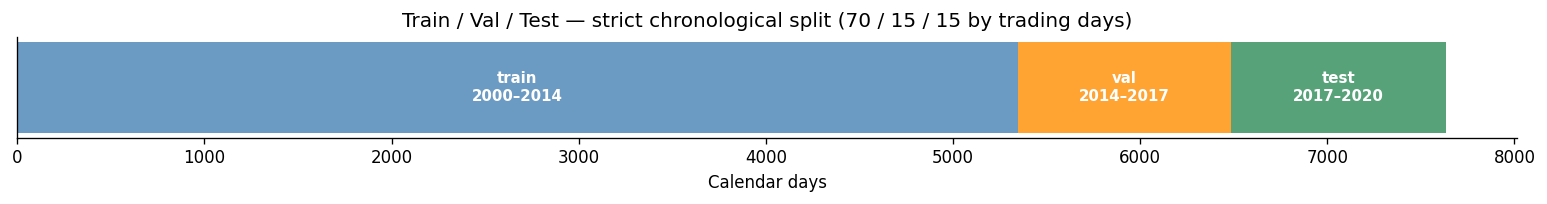


Split boundaries:
  train : 2000-01-03 → 2014-08-22
  val   : 2014-08-25 → 2017-10-10
  test  : 2017-10-11 → 2020-11-30


In [17]:
from src.utils import generate_date_split

splits = generate_date_split(feat, df_to_join=[], date_col='date',
                             train_split=0.70, val_split=0.15)

fig, ax = plt.subplots(figsize=(13, 1.8))
split_colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'seagreen'}
left = 0
for name, (start, end) in splits.items():
    width = (end - start).days
    ax.barh(0, width, left=left, color=split_colors[name], alpha=0.8, height=0.5)
    ax.text(left + width / 2, 0, f'{name}\n{start.year}–{end.year}',
            ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    left += width
ax.set_yticks([])
ax.set_xlabel('Calendar days')
ax.set_title('Train / Val / Test — strict chronological split (70 / 15 / 15 by trading days)')
plt.tight_layout()
plt.savefig(f'{config.PLOTS_DIR}/date_splits.png', bbox_inches='tight')
plt.show()

print('\nSplit boundaries:')
for name, (start, end) in splits.items():
    print(f'  {name:6s}: {start.date()} → {end.date()}')

**Rationale:** Models are trained on 2000–2015 (covering the dot-com crash and GFC), validated on 2015–2018 (low-vol bull market), and tested on 2018–2021 (includes COVID shock). This ensures the test period contains an out-of-sample regime unseen during training.